In [1]:
import importlib.util
import subprocess
import sys

packages = [
    "kagglehub",
    "timm>=1.0.0",
    "torchmetrics",
    "ultralytics>=8.4.0",
    "onnx",
    "onnxscript",
    "onnxruntime",
    "scikit-learn",
    "pandas",
    "numpy",
    "matplotlib",
    "tqdm",
]

for package in packages:
    module = package.split(">=")[0].replace("-", "_")
    if module == "scikit_learn":
        module = "sklearn"
    if importlib.util.find_spec(module) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print("Dependencies are ready.")

Dependencies are ready.


In [2]:
import gc
import hashlib
import json
import os
import random
import re
import shutil
import subprocess
import time
import warnings
from pathlib import Path

os.environ["PYTHONHASHSEED"] = "42"
os.environ.setdefault("HF_HUB_DISABLE_IMPLICIT_TOKEN", "1")
os.environ.setdefault("TOKENIZERS_PARALLELISM", "false")
os.environ.setdefault("CUBLAS_WORKSPACE_CONFIG", ":4096:8")

import kagglehub
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as tv_models
import torchvision.transforms as transforms
from IPython.display import display
from PIL import Image
from sklearn.metrics import accuracy_score, classification_report, cohen_kappa_score, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision.transforms import InterpolationMode
from tqdm.auto import tqdm
from ultralytics import YOLO

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
try:
    torch.use_deterministic_algorithms(True, warn_only=True)
except Exception:
    pass
if torch.cuda.is_available():
    torch.backends.cuda.matmul.allow_tf32 = False
    torch.backends.cudnn.allow_tf32 = False
try:
    torch.set_float32_matmul_precision("highest")
except Exception:
    pass

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PROJECT_ROOT = Path.cwd()
DATASET_ROOT = PROJECT_ROOT / "uynnhy" / "processed-images"
OUTPUT_DIR = PROJECT_ROOT / "ce_asl_convnext_tiny_yolo26m_reproducible_outputs"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
EXPORT_DIR = OUTPUT_DIR / "exports"
YOLO_DATA_DIR = OUTPUT_DIR / "yolo_dataset"
YOLO_RUNS_DIR = OUTPUT_DIR / "yolo_runs"
REPORT_DIR = OUTPUT_DIR / "reports"
PLOT_DIR = OUTPUT_DIR / "plots"
MANIFEST_PATH = REPORT_DIR / "fixed_split_manifest_seed42.csv"
LEAKAGE_REPORT_PATH = REPORT_DIR / "leakage_report_seed42.json"

for directory in [CHECKPOINT_DIR, EXPORT_DIR, YOLO_DATA_DIR, YOLO_RUNS_DIR, REPORT_DIR, PLOT_DIR, DATASET_ROOT.parent]:
    directory.mkdir(parents=True, exist_ok=True)

CLASS_DIRS = ["1. Healthy", "2. BG", "3. WSSV", "4. WSSV_BG"]
CLASS_NAMES = ["Healthy", "BG", "WSSV", "WSSV_BG"]
CLASS_TO_IDX = {folder: idx for idx, folder in enumerate(CLASS_DIRS)}
NUM_CLASSES = len(CLASS_DIRS)
IMG_SIZE = 224
EPOCHS = 100
PATIENCE = 10
PAPER_BATCH_SIZE = 128
MICRO_BATCH_SIZE = 32
ACCUMULATION_STEPS = max(1, PAPER_BATCH_SIZE // MICRO_BATCH_SIZE)
EVAL_BATCH_SIZE = PAPER_BATCH_SIZE
YOLO_BATCH_SIZE = PAPER_BATCH_SIZE
WARMUP_EPOCHS = 5
WARMUP_HEAD_LR = 1e-3
BACKBONE_FINETUNE_LR = 2e-5
HEAD_FINETUNE_LR = 1e-4
STEP_SIZE = 3
STEP_GAMMA = 0.9
NUM_WORKERS = min(8, max(2, (os.cpu_count() or 4) // 2))
ENABLE_GPU_LOGGING = True
GPU_LOG_EVERY_N_EPOCHS = 1
USE_AMP = torch.cuda.is_available()
AMP_DTYPE = torch.float16
PIN_MEMORY = torch.cuda.is_available()
PERSISTENT_WORKERS = NUM_WORKERS > 0
TIMM_MODELS = ["convnext_tiny"]
YOLO_MODELS = ["yolo26m-cls"]
LOSS_RUNS = ["ce", "asl"]
LOSS_LABELS = {"ce": "CE", "asl": "ASL"}
LOSS_PAPERS = {"ce": "Sparse Categorical Cross-Entropy baseline from ShrimpXNet-style 4-class softmax training", "asl": "Asymmetric Loss For Multi-Label Classification"}
RUN_EXPORT_AFTER_TRAINING = False

def has_class_folders(path):
    return all((path / class_dir).exists() for class_dir in CLASS_DIRS)

def find_processed_images_dir(root):
    if has_class_folders(root):
        return root
    for candidate in [root / "processed_images", root / "processed-images", root / "data", root / "dataset"]:
        if has_class_folders(candidate):
            return candidate
    if root.exists():
        for candidate in sorted([p for p in root.rglob("*") if p.is_dir()]):
            if has_class_folders(candidate):
                return candidate
    return None

def materialize_dataset():
    existing = find_processed_images_dir(DATASET_ROOT)
    if existing is not None:
        print(f"Dataset already available at: {existing}")
        return existing
    cache_path = Path(kagglehub.dataset_download("uynnhy/processed-images"))
    print(f"KaggleHub cache path: {cache_path}")
    if DATASET_ROOT.exists() and not any(DATASET_ROOT.iterdir()):
        shutil.rmtree(DATASET_ROOT)
    shutil.copytree(cache_path, DATASET_ROOT, dirs_exist_ok=True)
    resolved = find_processed_images_dir(DATASET_ROOT)
    if resolved is None:
        raise RuntimeError(f"Could not find class folders under {DATASET_ROOT}")
    return resolved

def gpu_status_text():
    if not torch.cuda.is_available():
        return "CUDA unavailable"
    allocated = torch.cuda.memory_allocated() / 1024**2
    reserved = torch.cuda.memory_reserved() / 1024**2
    max_allocated = torch.cuda.max_memory_allocated() / 1024**2
    text = f"torch CUDA memory allocated/reserved/max: {allocated:.1f}/{reserved:.1f}/{max_allocated:.1f} MB"
    try:
        completed = subprocess.run(["nvidia-smi", "--query-gpu=utilization.gpu,memory.used,memory.total,power.draw,temperature.gpu", "--format=csv,noheader,nounits"], capture_output=True, text=True, timeout=5)
        if completed.returncode == 0 and completed.stdout.strip():
            util, mem_used, mem_total, power, temp = [part.strip() for part in completed.stdout.strip().split(",")]
            text += f" | nvidia-smi util={util}% mem={mem_used}/{mem_total} MB power={power} W temp={temp} C"
        else:
            text += f" | nvidia-smi failed: {completed.stderr.strip()[-200:]}"
    except Exception as exc:
        text += f" | nvidia-smi unavailable: {type(exc).__name__}: {exc}"
    return text

def print_gpu_status(label):
    if ENABLE_GPU_LOGGING:
        print(f"[GPU] {label}: {gpu_status_text()}")

def seed_worker(worker_id):
    worker_seed = SEED + worker_id
    np.random.seed(worker_seed)
    random.seed(worker_seed)
    torch.manual_seed(worker_seed)

DATA_DIR = materialize_dataset()
print(f"Project root: {PROJECT_ROOT}")
print(f"Dataset root: {DATASET_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Output directory: {OUTPUT_DIR}")
print(f"NUM_WORKERS: {NUM_WORKERS}")
print_gpu_status("startup")

/opt/miniconda3/lib/python3.13/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.1.0)/charset_normalizer (3.4.5) doesn't match a supported version!
  warnings.warn(


Using device: cuda
GPU: NVIDIA GeForce RTX 4090
Dataset already available at: /home/drnguyenvinh/notebooks/uynnhy/processed-images/processed_images
Project root: /home/drnguyenvinh/notebooks
Dataset root: /home/drnguyenvinh/notebooks/uynnhy/processed-images
Data directory: /home/drnguyenvinh/notebooks/uynnhy/processed-images/processed_images
Output directory: /home/drnguyenvinh/notebooks/ce_asl_convnext_tiny_yolo26m_reproducible_outputs
NUM_WORKERS: 8
[GPU] startup: torch CUDA memory allocated/reserved/max: 0.0/0.0/0.0 MB | nvidia-smi util=26% mem=485/24564 MB power=12.94 W temp=51 C


In [3]:
def discover_processed_images(data_dir):
    rows = []
    for class_dir in CLASS_DIRS:
        folder = data_dir / class_dir
        if not folder.exists():
            print(f"Warning: missing class folder: {folder}")
            continue
        for path in sorted(folder.iterdir()):
            if path.suffix.lower() in {".jpg", ".jpeg", ".png", ".bmp", ".webp"}:
                rows.append({"path": str(path), "rel_path": path.relative_to(data_dir).as_posix(), "class_dir": class_dir, "label": CLASS_TO_IDX[class_dir]})
    frame = pd.DataFrame(rows).sort_values("rel_path").reset_index(drop=True)
    if frame.empty:
        raise RuntimeError(f"No images found under {data_dir}.")
    return frame

def build_or_load_split(frame):
    if MANIFEST_PATH.exists():
        manifest = pd.read_csv(MANIFEST_PATH)
        merged = frame.merge(manifest[["rel_path", "split"]], on="rel_path", how="left")
        if merged["split"].isna().any():
            missing = int(merged["split"].isna().sum())
            raise RuntimeError(f"Existing manifest does not cover {missing} current files. Delete {MANIFEST_PATH} to rebuild.")
        train = merged[merged["split"] == "train"].copy()
        val = merged[merged["split"] == "val"].copy()
        test = merged[merged["split"] == "test"].copy()
        return train, val, test, manifest
    train, tmp = train_test_split(frame, test_size=0.30, stratify=frame["label"], random_state=SEED, shuffle=True)
    val, test = train_test_split(tmp, test_size=0.50, stratify=tmp["label"], random_state=SEED, shuffle=True)
    manifest = pd.concat([
        train.assign(split="train"),
        val.assign(split="val"),
        test.assign(split="test"),
    ], axis=0).sort_values("rel_path").reset_index(drop=True)
    manifest[["rel_path", "class_dir", "label", "split"]].to_csv(MANIFEST_PATH, index=False)
    return train.copy(), val.copy(), test.copy(), manifest

def file_md5(path, block_size=1 << 20):
    h = hashlib.md5()
    with Path(path).open("rb") as f:
        while True:
            block = f.read(block_size)
            if not block:
                break
            h.update(block)
    return h.hexdigest()

def split_leakage_report(train, val, test):
    report = {}
    split_frames = {"train": train, "val": val, "test": test}
    for name, split_frame in split_frames.items():
        report[f"{name}_size"] = int(len(split_frame))
        report[f"{name}_class_counts"] = split_frame["class_dir"].value_counts().reindex(CLASS_DIRS, fill_value=0).astype(int).to_dict()
    for a_name, a_frame in split_frames.items():
        for b_name, b_frame in split_frames.items():
            if a_name >= b_name:
                continue
            a_paths = set(a_frame["rel_path"])
            b_paths = set(b_frame["rel_path"])
            report[f"{a_name}_{b_name}_path_overlap"] = len(a_paths & b_paths)
    md5_frame = pd.concat([train.assign(split="train"), val.assign(split="val"), test.assign(split="test")], axis=0).copy()
    md5_frame["md5"] = [file_md5(path) for path in tqdm(md5_frame["path"].tolist(), desc="MD5", leave=False)]
    for a_name, a_frame in md5_frame.groupby("split"):
        for b_name, b_frame in md5_frame.groupby("split"):
            if a_name >= b_name:
                continue
            report[f"{a_name}_{b_name}_md5_overlap"] = len(set(a_frame["md5"]) & set(b_frame["md5"]))
    LEAKAGE_REPORT_PATH.write_text(json.dumps(report, indent=2), encoding="utf-8")
    return report

df = discover_processed_images(DATA_DIR)
train_df, val_df, test_df, split_manifest = build_or_load_split(df)
CLASS_COUNTS = train_df["label"].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=1).astype(int).tolist()
leakage_report = split_leakage_report(train_df, val_df, test_df)
print(f"Loaded {len(df)} processed images from {DATA_DIR}")
print(f"Train class counts: {dict(zip(CLASS_NAMES, CLASS_COUNTS))}")
print(json.dumps(leakage_report, indent=2))
display(pd.DataFrame({"class": CLASS_NAMES, "train": train_df["label"].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=0).astype(int).tolist(), "val": val_df["label"].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=0).astype(int).tolist(), "test": test_df["label"].value_counts().sort_index().reindex(range(NUM_CLASSES), fill_value=0).astype(int).tolist()}))

MD5:   0%|          | 0/1149 [00:00<?, ?it/s]

Loaded 1149 processed images from /home/drnguyenvinh/notebooks/uynnhy/processed-images/processed_images
Train class counts: {'Healthy': 282, 'BG': 139, 'WSSV': 229, 'WSSV_BG': 154}
{
  "train_size": 804,
  "train_class_counts": {
    "1. Healthy": 282,
    "2. BG": 139,
    "3. WSSV": 229,
    "4. WSSV_BG": 154
  },
  "val_size": 172,
  "val_class_counts": {
    "1. Healthy": 60,
    "2. BG": 30,
    "3. WSSV": 49,
    "4. WSSV_BG": 33
  },
  "test_size": 173,
  "test_class_counts": {
    "1. Healthy": 61,
    "2. BG": 29,
    "3. WSSV": 50,
    "4. WSSV_BG": 33
  },
  "train_val_path_overlap": 0,
  "test_train_path_overlap": 0,
  "test_val_path_overlap": 0,
  "test_train_md5_overlap": 0,
  "test_val_md5_overlap": 0,
  "train_val_md5_overlap": 0
}


,class,train,val,test
0,Healthy,282,60,61
1,BG,139,30,29
2,WSSV,229,49,50
3,WSSV_BG,154,33,33


In [4]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize(256, interpolation=InterpolationMode.BICUBIC, antialias=True),
    transforms.RandomResizedCrop(IMG_SIZE, scale=(0.82, 1.0), ratio=(0.90, 1.10), interpolation=InterpolationMode.BICUBIC, antialias=True),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=10, interpolation=InterpolationMode.BICUBIC),
    transforms.ColorJitter(brightness=0.10, contrast=0.10, saturation=0.05),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize(236, interpolation=InterpolationMode.BICUBIC, antialias=True),
    transforms.CenterCrop(IMG_SIZE),
    transforms.ToTensor(),
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

class ShrimpFrameDataset(Dataset):
    def __init__(self, frame, transform=None):
        self.frame = frame.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.frame)

    def __getitem__(self, index):
        row = self.frame.iloc[index]
        image = Image.open(row["path"]).convert("RGB")
        if self.transform is not None:
            image = self.transform(image)
        label = int(row["label"])
        return image, label

train_loader_generator = torch.Generator()
train_loader_generator.manual_seed(SEED)
eval_loader_generator = torch.Generator()
eval_loader_generator.manual_seed(SEED)

train_dataset = ShrimpFrameDataset(train_df, train_transform)
val_dataset = ShrimpFrameDataset(val_df, eval_transform)
test_dataset = ShrimpFrameDataset(test_df, eval_transform)
train_loader = DataLoader(train_dataset, batch_size=MICRO_BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=PERSISTENT_WORKERS, worker_init_fn=seed_worker, generator=train_loader_generator)
val_loader = DataLoader(val_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=PERSISTENT_WORKERS, worker_init_fn=seed_worker, generator=eval_loader_generator)
test_loader = DataLoader(test_dataset, batch_size=EVAL_BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, persistent_workers=PERSISTENT_WORKERS, worker_init_fn=seed_worker, generator=eval_loader_generator)
print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Train batches: 26 | Val batches: 2 | Test batches: 2


In [5]:
class ASLSingleLabel(nn.Module):
    def __init__(self, gamma_pos=0, gamma_neg=4, eps=0.1, reduction="mean"):
        super().__init__()
        self.eps = eps
        self.logsoftmax = nn.LogSoftmax(dim=-1)
        self.gamma_pos = gamma_pos
        self.gamma_neg = gamma_neg
        self.reduction = reduction

    def forward(self, inputs, target):
        target = target.long().view(-1)
        num_classes = inputs.size(-1)
        log_preds = self.logsoftmax(inputs)
        targets = torch.zeros_like(inputs).scatter_(1, target.unsqueeze(1), 1)
        anti_targets = 1 - targets
        xs_pos = torch.exp(log_preds) * targets
        xs_neg = (1 - torch.exp(log_preds)) * anti_targets
        asymmetric_w = torch.pow(1 - xs_pos - xs_neg, self.gamma_pos * targets + self.gamma_neg * anti_targets)
        log_preds = log_preds * asymmetric_w
        if self.eps > 0:
            targets = targets.mul(1 - self.eps).add(self.eps / num_classes)
        loss = -targets.mul(log_preds).sum(dim=-1)
        if self.reduction == "mean":
            return loss.mean()
        if self.reduction == "sum":
            return loss.sum()
        return loss

def make_loss(loss_name):
    if loss_name == "ce":
        return nn.CrossEntropyLoss()
    if loss_name == "asl":
        return ASLSingleLabel(gamma_pos=0, gamma_neg=4, eps=0.1, reduction="mean")
    raise ValueError(loss_name)

In [6]:
TIMM_ALIASES = {
    "convnext_tiny": ["convnext_tiny.fb_in22k", "convnext_tiny.fb_in1k", "convnext_tiny"],
    "convnext_tiny_in22k": ["convnext_tiny.fb_in22k", "convnext_tiny.fb_in1k", "convnext_tiny"],
}

def sanitize_name(name):
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", name).strip("_")

def count_params(model):
    return sum(param.numel() for param in model.parameters()) / 1e6

def resolve_timm_name(display_name):
    candidates = TIMM_ALIASES.get(display_name, [display_name])
    available = set(timm.list_models(pretrained=False))
    for candidate in candidates:
        if candidate in available:
            return candidate
    pattern_hits = []
    for candidate in candidates:
        pattern_hits.extend(timm.list_models(candidate + "*", pretrained=False))
    if pattern_hits:
        return sorted(pattern_hits)[0]
    raise ValueError(f"No TIMM model found for {display_name}. Tried: {candidates}")

class TimmShrimpXNet(nn.Module):
    def __init__(self, timm_name, pretrained):
        super().__init__()
        try:
            self.backbone = timm.create_model(timm_name, pretrained=pretrained, num_classes=0, global_pool="avg")
        except TypeError:
            self.backbone = timm.create_model(timm_name, pretrained=pretrained, num_classes=0)
        was_training = self.backbone.training
        self.backbone.eval()
        with torch.no_grad():
            sample = torch.randn(1, 3, IMG_SIZE, IMG_SIZE)
            features = self.backbone(sample)
            if isinstance(features, (list, tuple)):
                features = features[-1]
            num_features = features.flatten(1).shape[1]
        self.backbone.train(was_training)
        self.classifier = nn.Sequential(nn.Linear(num_features, 512), nn.ReLU(inplace=True), nn.Dropout(p=0.5), nn.Linear(512, NUM_CLASSES))

    def forward(self, x):
        x = self.backbone(x)
        if isinstance(x, (list, tuple)):
            x = x[-1]
        x = torch.flatten(x, 1)
        return self.classifier(x)

def create_timm_classifier(display_name):
    timm_name = resolve_timm_name(display_name)
    try:
        model = TimmShrimpXNet(timm_name, pretrained=True)
        pretrained = True
    except Exception as pretrained_error:
        print(f"Pretrained weights failed for {display_name} ({timm_name}): {type(pretrained_error).__name__}: {pretrained_error}")
        model = TimmShrimpXNet(timm_name, pretrained=False)
        pretrained = False
    return model.to(device), timm_name, pretrained

def classifier_parameters(model):
    if hasattr(model, "classifier"):
        return list(model.classifier.parameters())
    params = []
    classifier = model.get_classifier() if hasattr(model, "get_classifier") else None
    if isinstance(classifier, nn.Module):
        params = list(classifier.parameters())
    elif isinstance(classifier, (list, tuple, nn.ModuleList)):
        for module in classifier:
            if isinstance(module, nn.Module):
                params.extend(list(module.parameters()))
    if not params:
        head_tokens = ("classifier", "head", "fc")
        params = [param for name, param in model.named_parameters() if any(token in name.lower() for token in head_tokens)]
    if not params:
        raise RuntimeError("Could not identify classifier/head parameters for warmup.")
    return params

def freeze_backbone_for_warmup(model):
    for param in model.parameters():
        param.requires_grad = False
    for param in classifier_parameters(model):
        param.requires_grad = True

def make_warmup_optimizer(model):
    return optim.Adam([param for param in model.parameters() if param.requires_grad], lr=WARMUP_HEAD_LR)

def unfreeze_module(module):
    for param in module.parameters():
        param.requires_grad = True

def unfreeze_final_backbone_portion(model, display_name):
    backbone = model.backbone if hasattr(model, "backbone") else model
    trainable_modules = []
    for param in model.parameters():
        param.requires_grad = False
    for param in classifier_parameters(model):
        param.requires_grad = True
    if hasattr(backbone, "features") and isinstance(backbone.features, (nn.Sequential, nn.ModuleList, list, tuple)):
        features = backbone.features
        if "convnext" in display_name.lower() and len(features) > 5:
            selected = list(features[5:])
        else:
            start = max(0, len(features) - max(1, len(features) // 3))
            selected = list(features[start:])
        trainable_modules.extend(selected)
    elif hasattr(backbone, "stages") and isinstance(backbone.stages, (nn.Sequential, nn.ModuleList, list, tuple)):
        stages = backbone.stages
        start = max(0, len(stages) - max(1, len(stages) // 3))
        trainable_modules.extend(list(stages[start:]))
    elif hasattr(backbone, "blocks") and isinstance(backbone.blocks, (nn.Sequential, nn.ModuleList, list, tuple)):
        blocks = backbone.blocks
        start = max(0, len(blocks) - max(1, len(blocks) // 3))
        trainable_modules.extend(list(blocks[start:]))
    else:
        excluded = {"classifier", "head", "fc", "global_pool", "pool", "avgpool"}
        children = [child for name, child in backbone.named_children() if name not in excluded and not name.startswith("head")]
        trainable_modules.extend(children[-2:] if len(children) >= 2 else children)
    for attr in ["norm", "norm_head", "head_norm", "pre_head", "final_conv"]:
        module = getattr(backbone, attr, None)
        if isinstance(module, nn.Module):
            trainable_modules.append(module)
    for module in trainable_modules:
        unfreeze_module(module)
    return sum(param.numel() for param in model.parameters() if param.requires_grad)

def make_finetune_optimizer(model):
    head_param_ids = {id(param) for param in classifier_parameters(model)}
    backbone_params = []
    head_params = []
    for param in model.parameters():
        if not param.requires_grad:
            continue
        if id(param) in head_param_ids:
            head_params.append(param)
        else:
            backbone_params.append(param)
    param_groups = []
    if backbone_params:
        param_groups.append({"params": backbone_params, "lr": BACKBONE_FINETUNE_LR})
    if head_params:
        param_groups.append({"params": head_params, "lr": HEAD_FINETUNE_LR})
    return optim.Adam(param_groups)

def extract_logits(output):
    if isinstance(output, torch.Tensor):
        return output
    if isinstance(output, (list, tuple)):
        tensors = [item for item in output if isinstance(item, torch.Tensor)]
        if tensors:
            return tensors[-1]
    if hasattr(output, "logits"):
        return output.logits
    raise TypeError(f"Unsupported model output type: {type(output)}")

def forward_with_amp(model, ims):
    with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
        return extract_logits(model(ims))

def metric_dict_from_labels_preds(labels, preds):
    return {
        "accuracy": accuracy_score(labels, preds),
        "precision": precision_score(labels, preds, average="macro", zero_division=0),
        "recall": recall_score(labels, preds, average="macro", zero_division=0),
        "macro_f1": f1_score(labels, preds, average="macro", zero_division=0),
        "cohen_kappa": cohen_kappa_score(labels, preds),
    }

def predict_pytorch(model, loader, criterion=None, timed=False):
    model.eval()
    total_loss = 0.0
    all_labels = []
    all_preds = []
    if timed:
        dummy = torch.randn(1, 3, IMG_SIZE, IMG_SIZE, device=device)
        with torch.no_grad():
            for _ in range(10):
                model(dummy)
            if torch.cuda.is_available():
                torch.cuda.synchronize()
        start = time.time()
    else:
        start = None
    with torch.no_grad():
        for ims, gts in loader:
            ims = ims.to(device, non_blocking=True)
            gts = gts.to(device, non_blocking=True)
            logits = forward_with_amp(model, ims)
            if criterion is not None:
                total_loss += criterion(logits.float(), gts).item() * ims.size(0)
            preds = torch.argmax(logits, dim=1)
            all_labels.extend(gts.cpu().numpy().tolist())
            all_preds.extend(preds.cpu().numpy().tolist())
    if timed and torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.time() - start if timed else None
    metrics = metric_dict_from_labels_preds(all_labels, all_preds)
    metrics.update({"loss": total_loss / max(1, len(all_labels)) if criterion is not None else None, "elapsed": elapsed, "labels": all_labels, "preds": all_preds})
    return metrics

def save_confusion_matrix(labels, preds, title, path):
    matrix = confusion_matrix(labels, preds, labels=list(range(NUM_CLASSES)))
    fig, ax = plt.subplots(figsize=(6.5, 5.5))
    im = ax.imshow(matrix)
    ax.set_xticks(range(NUM_CLASSES))
    ax.set_xticklabels(CLASS_NAMES, rotation=45, ha="right")
    ax.set_yticks(range(NUM_CLASSES))
    ax.set_yticklabels(CLASS_NAMES)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    for i in range(NUM_CLASSES):
        for j in range(NUM_CLASSES):
            ax.text(j, i, int(matrix[i, j]), ha="center", va="center")
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    fig.tight_layout()
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)

def save_classification_report(labels, preds, path):
    report = classification_report(labels, preds, labels=list(range(NUM_CLASSES)), target_names=CLASS_NAMES, output_dict=True, zero_division=0)
    pd.DataFrame(report).transpose().to_csv(path)
    return report

def new_grad_scaler():
    try:
        return torch.amp.GradScaler("cuda", enabled=USE_AMP)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=USE_AMP)

In [7]:
def train_timm_model(model_name, loss_name):
    loss_label = LOSS_LABELS[loss_name]
    run_name = sanitize_name(f"{model_name}_{loss_name}")
    print("\n" + "=" * 90)
    print(f"Training TIMM classifier: {model_name} | {loss_label}")
    print("=" * 90)
    model, timm_name, pretrained = create_timm_classifier(model_name)
    print(f"Resolved TIMM model: {timm_name} | pretrained={pretrained}")
    print_gpu_status(f"{model_name} {loss_label} after model.to(device)")
    criterion = make_loss(loss_name).to(device)
    best_path = CHECKPOINT_DIR / f"best_{run_name}.pth"
    if best_path.exists():
        best_path.unlink()
    best_val_loss = float("inf")
    best_val_f1 = -1.0
    best_epoch = 0
    epochs_no_improve = 0
    history = []
    train_start = time.time()
    freeze_backbone_for_warmup(model)
    print(f"Warmup trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    optimizer = make_warmup_optimizer(model)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=STEP_GAMMA)
    scaler = new_grad_scaler()
    for epoch in range(EPOCHS):
        if epoch == WARMUP_EPOCHS:
            print("\n--- Switching to fine-tuning phase: unfreezing backbone with lower LR ---")
            trainable_count = unfreeze_final_backbone_portion(model, model_name)
            print(f"Fine-tune trainable parameters: {trainable_count:,}")
            optimizer = make_finetune_optimizer(model)
            scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=STEP_SIZE, gamma=STEP_GAMMA)
            epochs_no_improve = 0
        model.train()
        train_loss = 0.0
        train_correct = 0
        train_total = 0
        current_lrs = [group["lr"] for group in optimizer.param_groups]
        optimizer.zero_grad(set_to_none=True)
        for step, (ims, gts) in enumerate(tqdm(train_loader, desc=f"{model_name} {loss_label} epoch {epoch + 1}/{EPOCHS}", leave=False)):
            ims = ims.to(device, non_blocking=True)
            gts = gts.to(device, non_blocking=True)
            with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=USE_AMP):
                logits = extract_logits(model(ims))
                loss = criterion(logits.float(), gts)
                scaled_loss = loss / ACCUMULATION_STEPS
            scaler.scale(scaled_loss).backward()
            if (step + 1) % ACCUMULATION_STEPS == 0 or (step + 1) == len(train_loader):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], max_norm=1.0)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)
            train_loss += loss.item() * ims.size(0)
            train_correct += (torch.argmax(logits, dim=1) == gts).sum().item()
            train_total += gts.size(0)
        scheduler.step()
        val_metrics = predict_pytorch(model, val_loader, criterion=criterion, timed=False)
        if (epoch + 1) % GPU_LOG_EVERY_N_EPOCHS == 0:
            print_gpu_status(f"{model_name} {loss_label} epoch {epoch + 1} end")
        train_acc = train_correct / max(1, train_total)
        phase = "warmup" if epoch < WARMUP_EPOCHS else "finetune"
        lr_text = ",".join(f"{lr:.2e}" for lr in current_lrs)
        epoch_record = {"Model": model_name, "Backend": "timm", "Loss": loss_label, "Loss Key": loss_name, "Epoch": epoch + 1, "Phase": phase, "LR": lr_text, "Train Loss": train_loss / max(1, train_total), "Train Accuracy": train_acc, "Val Loss": val_metrics["loss"], "Val Accuracy": val_metrics["accuracy"], "Val Precision": val_metrics["precision"], "Val Recall": val_metrics["recall"], "Val F1-Score": val_metrics["macro_f1"], "Val Cohen Kappa": val_metrics["cohen_kappa"]}
        history.append(epoch_record)
        pd.DataFrame(history).to_csv(REPORT_DIR / f"history_{run_name}.csv", index=False)
        print(f"Epoch {epoch + 1:02d}/{EPOCHS} | Phase: {phase} | LR: {lr_text} | Train Loss: {epoch_record['Train Loss']:.4f} - Acc: {train_acc:.4f} | Val Loss: {val_metrics['loss']:.4f} - Acc: {val_metrics['accuracy']:.4f} - Macro F1: {val_metrics['macro_f1']:.4f}")
        improved = val_metrics["loss"] < best_val_loss
        if improved:
            best_val_loss = val_metrics["loss"]
            best_val_f1 = val_metrics["macro_f1"]
            best_epoch = epoch + 1
            epochs_no_improve = 0
            torch.save({"model_state_dict": model.state_dict(), "display_name": model_name, "timm_name": timm_name, "backend_source": "timm", "pretrained": pretrained, "loss": loss_name, "loss_label": loss_label, "num_classes": NUM_CLASSES, "img_size": IMG_SIZE, "class_names": CLASS_NAMES, "seed": SEED, "split_manifest": str(MANIFEST_PATH)}, best_path)
            print(f"  --> Saved best checkpoint: val loss {best_val_loss:.4f}, macro F1 {best_val_f1:.4f}")
        else:
            epochs_no_improve += 1
            print(f"  --> No improvement ({epochs_no_improve}/{PATIENCE})")
        if epochs_no_improve >= PATIENCE:
            print("  --> Early stopping triggered.")
            break
    train_time = time.time() - train_start
    checkpoint = torch.load(best_path, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    val_metrics = predict_pytorch(model, val_loader, criterion=criterion, timed=False)
    test_metrics = predict_pytorch(model, test_loader, criterion=None, timed=True)
    inf_time = max(test_metrics["elapsed"], 1e-9)
    params_m = count_params(model)
    cm_path = PLOT_DIR / f"confusion_matrix_{run_name}.png"
    report_path = REPORT_DIR / f"classification_report_{run_name}.csv"
    save_confusion_matrix(test_metrics["labels"], test_metrics["preds"], f"{model_name} | {loss_label}", cm_path)
    save_classification_report(test_metrics["labels"], test_metrics["preds"], report_path)
    result = {"Model": model_name, "Backend": "timm", "Backend Name": timm_name, "Loss": loss_label, "Loss Key": loss_name, "Loss Paper": LOSS_PAPERS[loss_name], "Selection Metric": "min_val_loss", "Parameters (M)": round(params_m, 2), "Training Time (s)": round(train_time, 1), "Best Epoch": best_epoch, "Best Val Loss": round(best_val_loss, 6), "Best Val Top1": round(val_metrics["accuracy"], 4), "Val Accuracy": round(val_metrics["accuracy"], 4), "Val Precision": round(val_metrics["precision"], 4), "Val Recall": round(val_metrics["recall"], 4), "Val F1-Score": round(val_metrics["macro_f1"], 4), "Val Cohen Kappa": round(val_metrics["cohen_kappa"], 4), "Test Accuracy": round(test_metrics["accuracy"], 4), "Test Precision": round(test_metrics["precision"], 4), "Test Recall": round(test_metrics["recall"], 4), "Test F1-Score": round(test_metrics["macro_f1"], 4), "Cohen Kappa": round(test_metrics["cohen_kappa"], 4), "Inference Time (s)": round(inf_time, 4), "FPS": round(len(test_df) / inf_time, 2), "Latency (ms)": round((inf_time / len(test_df)) * 1000, 4), "Checkpoint Path": str(best_path), "Confusion Matrix Path": str(cm_path), "Classification Report Path": str(report_path), "Export Format": "", "Export Path": "", "Export Note": ""}
    del model, optimizer, scheduler, criterion, scaler
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    return result, history

In [8]:
def prepare_yolo_dataset():
    if YOLO_DATA_DIR.exists():
        shutil.rmtree(YOLO_DATA_DIR)
    for split_name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
        for class_dir in CLASS_DIRS:
            (YOLO_DATA_DIR / split_name / class_dir).mkdir(parents=True, exist_ok=True)
        for _, row in split_df.iterrows():
            src = Path(row["path"])
            dst = YOLO_DATA_DIR / split_name / row["class_dir"] / src.name
            if dst.exists():
                dst = dst.with_name(f"{dst.stem}_{abs(hash(str(src))) % 10_000_000}{dst.suffix}")
            shutil.copy2(src, dst)
    print(f"Prepared YOLO classification dataset at {YOLO_DATA_DIR}")

prepare_yolo_dataset()

def yolo_device_arg():
    return 0 if torch.cuda.is_available() else "cpu"

try:
    from ultralytics.models.yolo.classify.train import ClassificationTrainer
except Exception:
    from ultralytics.models.yolo.classify import ClassificationTrainer
from ultralytics.nn.tasks import ClassificationModel

ACTIVE_YOLO_LOSS_NAME = "ce"
ACTIVE_YOLO_CLASS_COUNTS = CLASS_COUNTS

class LossAblationClassificationLoss(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.loss_name = getattr(model, "loss_name", ACTIVE_YOLO_LOSS_NAME)
        self.loss_fcn = make_loss(self.loss_name)

    def forward(self, preds, batch):
        preds = preds[1] if isinstance(preds, (list, tuple)) else preds
        targets = batch["cls"].long().view(-1).to(preds.device)
        if isinstance(self.loss_fcn, nn.Module):
            self.loss_fcn = self.loss_fcn.to(preds.device)
        loss = self.loss_fcn(preds.float(), targets)
        return loss, loss.detach()

class LossAblationClassificationModel(ClassificationModel):
    def init_criterion(self):
        return LossAblationClassificationLoss(self)

class ValLossSelectionClassificationTrainer(ClassificationTrainer):
    def get_model(self, cfg=None, weights=None, verbose=True):
        nc = self.data["nc"] if isinstance(self.data, dict) and "nc" in self.data else NUM_CLASSES
        channels = self.data.get("channels", 3) if isinstance(self.data, dict) else 3
        try:
            model = LossAblationClassificationModel(cfg, nc=nc, ch=channels, verbose=verbose)
        except TypeError:
            model = LossAblationClassificationModel(cfg, ch=channels, nc=nc, verbose=verbose)
        model.loss_name = ACTIVE_YOLO_LOSS_NAME
        model.cls_num_list = ACTIVE_YOLO_CLASS_COUNTS
        if weights:
            model.load(weights)
        return model

    def compute_custom_val_loss(self):
        criterion = make_loss(ACTIVE_YOLO_LOSS_NAME).to(self.device)
        model_for_loss = self.ema.ema if getattr(self, "ema", None) is not None and hasattr(self.ema, "ema") else self.model
        was_training = model_for_loss.training
        model_for_loss.eval()
        total_loss = 0.0
        total_n = 0
        with torch.no_grad():
            for batch in self.test_loader:
                batch = self.preprocess_batch(batch)
                images = batch["img"]
                targets = batch["cls"].long().view(-1)
                with torch.autocast(device_type="cuda", dtype=AMP_DTYPE, enabled=bool(getattr(self, "amp", False)) and self.device.type == "cuda"):
                    preds = model_for_loss(images)
                    logits = preds[1] if isinstance(preds, (list, tuple)) else preds
                    loss = criterion(logits.float(), targets)
                batch_n = int(images.shape[0])
                total_loss += float(loss.detach().cpu()) * batch_n
                total_n += batch_n
        model_for_loss.train(was_training)
        return total_loss / max(1, total_n)

    def validate(self):
        if getattr(self, "ema", None) is not None and getattr(self, "world_size", 1) > 1:
            try:
                import torch.distributed as dist
                for buffer in self.ema.ema.buffers():
                    dist.broadcast(buffer, src=0)
            except Exception:
                pass
        metrics = self.validator(self)
        if metrics is None:
            return None, None
        metrics.pop("fitness", None)
        custom_val_loss = self.compute_custom_val_loss()
        fitness = -float(custom_val_loss)
        metrics["custom/val_loss"] = float(custom_val_loss)
        metrics["custom/selection_fitness"] = float(fitness)
        if not self.best_fitness or self.best_fitness < fitness:
            self.best_fitness = fitness
        return metrics, fitness

def evaluate_yolo_model(yolo_model, eval_df, timed=False):
    names = yolo_model.names
    name_to_idx = {value: int(key) for key, value in names.items()}
    source_paths = eval_df["path"].tolist()
    if timed:
        _ = yolo_model.predict(source=source_paths[:1], imgsz=IMG_SIZE, device=yolo_device_arg(), verbose=False)
        if torch.cuda.is_available():
            torch.cuda.synchronize()
        start = time.time()
    else:
        start = None
    preds = yolo_model.predict(source=source_paths, imgsz=IMG_SIZE, batch=YOLO_BATCH_SIZE, device=yolo_device_arg(), verbose=False)
    if timed and torch.cuda.is_available():
        torch.cuda.synchronize()
    elapsed = time.time() - start if timed else None
    y_true = [name_to_idx[class_dir] for class_dir in eval_df["class_dir"].tolist()]
    y_pred = [int(result.probs.top1) for result in preds]
    metrics = metric_dict_from_labels_preds(y_true, y_pred)
    metrics.update({"elapsed": elapsed, "labels": y_true, "preds": y_pred})
    return metrics

def read_yolo_history(run_dir, model_name, loss_name):
    results_csv = run_dir / "results.csv"
    if not results_csv.exists():
        hits = sorted(run_dir.glob("**/results.csv"))
        if not hits:
            return []
        results_csv = hits[-1]
    frame = pd.read_csv(results_csv)
    frame.columns = [col.strip() for col in frame.columns]
    history = []
    for idx, row in frame.iterrows():
        record = {"Model": model_name, "Backend": "yolo", "Loss": LOSS_LABELS[loss_name], "Loss Key": loss_name, "Epoch": int(row.get("epoch", idx + 1))}
        for col in frame.columns:
            value = row[col]
            if pd.api.types.is_number(value):
                record[col] = value
        history.append(record)
    return history

def get_yolo_best_info(run_dir):
    results_csv = run_dir / "results.csv"
    if not results_csv.exists():
        hits = sorted(run_dir.glob("**/results.csv"))
        if not hits:
            return np.nan, np.nan, np.nan
        results_csv = hits[-1]
    frame = pd.read_csv(results_csv)
    frame.columns = [col.strip() for col in frame.columns]
    if "custom/val_loss" in frame.columns and not frame.empty:
        val_loss_series = pd.to_numeric(frame["custom/val_loss"], errors="coerce")
        idx = val_loss_series.idxmin()
        best_epoch = int(frame.loc[idx, "epoch"]) if "epoch" in frame.columns else int(idx) + 1
        best_val_loss = float(val_loss_series.loc[idx])
    else:
        best_epoch = np.nan
        best_val_loss = np.nan
    metric_candidates = ["metrics/accuracy_top1", "top1_acc", "accuracy_top1"]
    metric_col = next((col for col in metric_candidates if col in frame.columns), None)
    if metric_col is None:
        metric_col = next((col for col in frame.columns if "top1" in col.lower()), None)
    best_val_top1 = np.nan
    if metric_col is not None and not frame.empty:
        values = pd.to_numeric(frame[metric_col], errors="coerce")
        if "custom/val_loss" in frame.columns and not pd.isna(best_epoch):
            best_val_top1 = float(values.loc[idx])
        else:
            best_val_top1 = float(values.loc[values.idxmax()])
    return best_epoch, best_val_loss, best_val_top1

def train_yolo_model(model_name, loss_name):
    global ACTIVE_YOLO_LOSS_NAME, ACTIVE_YOLO_CLASS_COUNTS
    ACTIVE_YOLO_LOSS_NAME = loss_name
    ACTIVE_YOLO_CLASS_COUNTS = CLASS_COUNTS
    loss_label = LOSS_LABELS[loss_name]
    run_name = sanitize_name(f"{model_name}_{loss_name}")
    run_dir = YOLO_RUNS_DIR / run_name
    if run_dir.exists():
        shutil.rmtree(run_dir)
    print("\n" + "=" * 90)
    print(f"Training YOLO classifier: {model_name} | {loss_label}")
    print("=" * 90)
    weights_name = f"{model_name}.pt"
    train_start = time.time()
    yolo = YOLO(weights_name)
    print_gpu_status(f"{model_name} {loss_label} before YOLO train")
    train_kwargs = dict(data=str(YOLO_DATA_DIR), task="classify", imgsz=IMG_SIZE, epochs=EPOCHS, batch=YOLO_BATCH_SIZE, patience=PATIENCE, seed=SEED, deterministic=True, project=str(YOLO_RUNS_DIR), name=run_name, exist_ok=True, device=yolo_device_arg(), verbose=True, workers=NUM_WORKERS, amp=USE_AMP, optimizer="AdamW", lr0=1.25e-3, lrf=0.01, cos_lr=True, cache=True)
    yolo.train(trainer=ValLossSelectionClassificationTrainer, **train_kwargs)
    print_gpu_status(f"{model_name} {loss_label} after YOLO train")
    train_time = time.time() - train_start
    best_path = run_dir / "weights" / "best.pt"
    if not best_path.exists():
        candidates = sorted(run_dir.glob("**/best.pt"))
        if not candidates:
            raise FileNotFoundError(f"Could not locate YOLO best checkpoint for {model_name} {loss_label}")
        best_path = candidates[-1]
    best_yolo = YOLO(str(best_path))
    print_gpu_status(f"{model_name} {loss_label} before YOLO eval")
    val_metrics = evaluate_yolo_model(best_yolo, val_df, timed=False)
    test_metrics = evaluate_yolo_model(best_yolo, test_df, timed=True)
    print_gpu_status(f"{model_name} {loss_label} after YOLO eval")
    best_epoch, best_val_loss, best_val_top1 = get_yolo_best_info(run_dir)
    inf_time = max(test_metrics["elapsed"], 1e-9)
    params_m = count_params(best_yolo.model)
    cm_path = PLOT_DIR / f"confusion_matrix_{run_name}.png"
    report_path = REPORT_DIR / f"classification_report_{run_name}.csv"
    save_confusion_matrix(test_metrics["labels"], test_metrics["preds"], f"{model_name} | {loss_label}", cm_path)
    save_classification_report(test_metrics["labels"], test_metrics["preds"], report_path)
    history = read_yolo_history(run_dir, model_name, loss_name)
    result = {"Model": model_name, "Backend": "yolo", "Backend Name": weights_name, "Loss": loss_label, "Loss Key": loss_name, "Loss Paper": LOSS_PAPERS[loss_name], "Selection Metric": "min_val_loss", "Parameters (M)": round(params_m, 2), "Training Time (s)": round(train_time, 1), "Best Epoch": best_epoch, "Best Val Loss": round(best_val_loss, 6) if not pd.isna(best_val_loss) else np.nan, "Best Val Top1": round(best_val_top1, 4) if not pd.isna(best_val_top1) else np.nan, "Val Accuracy": round(val_metrics["accuracy"], 4), "Val Precision": round(val_metrics["precision"], 4), "Val Recall": round(val_metrics["recall"], 4), "Val F1-Score": round(val_metrics["macro_f1"], 4), "Val Cohen Kappa": round(val_metrics["cohen_kappa"], 4), "Test Accuracy": round(test_metrics["accuracy"], 4), "Test Precision": round(test_metrics["precision"], 4), "Test Recall": round(test_metrics["recall"], 4), "Test F1-Score": round(test_metrics["macro_f1"], 4), "Cohen Kappa": round(test_metrics["cohen_kappa"], 4), "Inference Time (s)": round(inf_time, 4), "FPS": round(len(test_df) / inf_time, 2), "Latency (ms)": round((inf_time / len(test_df)) * 1000, 4), "Checkpoint Path": str(best_path), "Confusion Matrix Path": str(cm_path), "Classification Report Path": str(report_path), "Export Format": "", "Export Path": "", "Export Note": ""}
    del yolo, best_yolo
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()
    return result, history

Prepared YOLO classification dataset at /home/drnguyenvinh/notebooks/ce_asl_convnext_tiny_yolo26m_reproducible_outputs/yolo_dataset



Training TIMM classifier: convnext_tiny | CE


Resolved TIMM model: convnext_tiny | pretrained=True
[GPU] convnext_tiny CE after model.to(device): torch CUDA memory allocated/reserved/max: 109.0/128.0/109.0 MB | nvidia-smi util=24% mem=1044/24564 MB power=17.57 W temp=51 C
Warmup trainable parameters: 395,780


convnext_tiny CE epoch 1/100:   0%|          | 0/26 [00:00<?, ?it/s]

[GPU] convnext_tiny CE epoch 1 end: torch CUDA memory allocated/reserved/max: 180.3/1946.0/1285.3 MB | nvidia-smi util=4% mem=2808/24564 MB power=59.39 W temp=54 C
Epoch 01/100 | Phase: warmup | LR: 1.00e-03 | Train Loss: 1.4729 - Acc: 0.3968 | Val Loss: 1.2319 - Acc: 0.4535 - Macro F1: 0.3801
  --> Saved best checkpoint: val loss 1.2319, macro F1 0.3801


convnext_tiny CE epoch 2/100:   0%|          | 0/26 [00:00<?, ?it/s]

...

[GPU] convnext_tiny CE epoch 38 end: torch CUDA memory allocated/reserved/max: 298.0/1952.0/1403.0 MB | nvidia-smi util=2% mem=2753/24564 MB power=65.49 W temp=51 C
Epoch 38/100 | Phase: finetune | LR: 6.97e-06,3.49e-05 | Train Loss: 0.0165 - Acc: 0.9963 | Val Loss: 0.5192 - Acc: 0.8547 - Macro F1: 0.8430
  --> No improvement (8/10)


convnext_tiny CE epoch 39/100:   0%|          | 0/26 [00:00<?, ?it/s]

[GPU] convnext_tiny CE epoch 39 end: torch CUDA memory allocated/reserved/max: 298.0/1952.0/1403.0 MB | nvidia-smi util=2% mem=2753/24564 MB power=66.65 W temp=51 C
Epoch 39/100 | Phase: finetune | LR: 6.28e-06,3.14e-05 | Train Loss: 0.0117 - Acc: 0.9988 | Val Loss: 0.5101 - Acc: 0.8663 - Macro F1: 0.8576
  --> No improvement (9/10)


convnext_tiny CE epoch 40/100:   0%|          | 0/26 [00:00<?, ?it/s]

[GPU] convnext_tiny CE epoch 40 end: torch CUDA memory allocated/reserved/max: 298.0/1952.0/1403.0 MB | nvidia-smi util=3% mem=2753/24564 MB power=68.27 W temp=51 C
Epoch 40/100 | Phase: finetune | LR: 6.28e-06,3.14e-05 | Train Loss: 0.0114 - Acc: 0.9975 | Val Loss: 0.5147 - Acc: 0.8721 - Macro F1: 0.8562
  --> No improvement (10/10)
  --> Early stopping triggered.


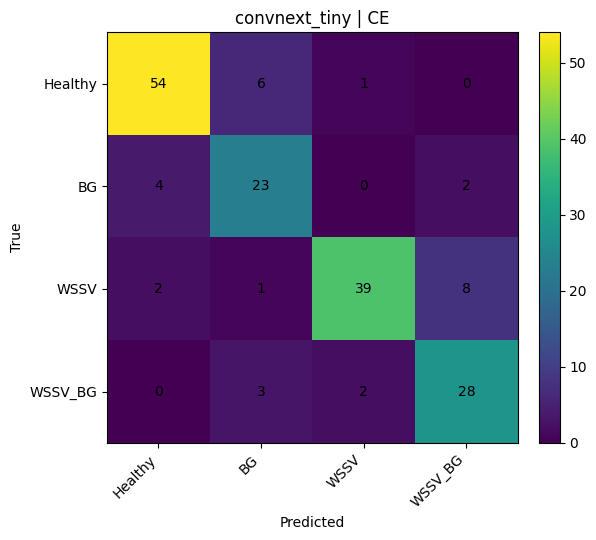

Recorded result:


,Model,Backend,Backend Name,Loss,Loss Key,Loss Paper,Selection Metric,Parameters (M),Training Time (s),Best Epoch,...,Cohen Kappa,Inference Time (s),FPS,Latency (ms),Checkpoint Path,Confusion Matrix Path,Classification Report Path,Export Format,Export Path,Export Note
0,convnext_tiny,timm,convnext_tiny,CE,ce,Sparse Categorical Cross-Entropy baseline from...,min_val_loss,28.22,752.9,30,...,0.7715,8.6459,20.01,49.9761,/home/drnguyenvinh/notebooks/ce_asl_convnext_t...,/home/drnguyenvinh/notebooks/ce_asl_convnext_t...,/home/drnguyenvinh/notebooks/ce_asl_convnext_t...,,,



Training TIMM classifier: convnext_tiny | ASL
Resolved TIMM model: convnext_tiny | pretrained=True
[GPU] convnext_tiny ASL after model.to(device): torch CUDA memory allocated/reserved/max: 173.0/184.0/1512.1 MB | nvidia-smi util=0% mem=1011/24564 MB power=72.69 W temp=53 C
Warmup trainable parameters: 395,780


convnext_tiny ASL epoch 1/100:   0%|          | 0/26 [00:00<?, ?it/s]

In [ ]:
TARGET_RUNS = []
for model_name in TIMM_MODELS:
    for loss_name in LOSS_RUNS:
        TARGET_RUNS.append({"Model": model_name, "Backend": "timm", "Loss": loss_name})
for model_name in YOLO_MODELS:
    for loss_name in LOSS_RUNS:
        TARGET_RUNS.append({"Model": model_name, "Backend": "yolo", "Loss": loss_name})

comparison_results = []
all_histories = []

for spec in TARGET_RUNS:
    model_name = spec["Model"]
    backend = spec["Backend"]
    loss_name = spec["Loss"]
    try:
        if backend == "timm":
            result, history = train_timm_model(model_name, loss_name)
        elif backend == "yolo":
            result, history = train_yolo_model(model_name, loss_name)
        else:
            raise ValueError(backend)
        comparison_results.append(result)
        all_histories.extend(history)
        print("Recorded result:")
        display(pd.DataFrame([result]))
    except Exception as exc:
        print(f"ERROR while running {model_name} | {backend} | {LOSS_LABELS[loss_name]}: {type(exc).__name__}: {exc}")
        comparison_results.append({"Model": model_name, "Backend": backend, "Backend Name": "", "Loss": LOSS_LABELS[loss_name], "Loss Key": loss_name, "Loss Paper": LOSS_PAPERS[loss_name], "Selection Metric": "min_val_loss", "Parameters (M)": np.nan, "Training Time (s)": np.nan, "Best Epoch": np.nan, "Best Val Loss": np.nan, "Best Val Top1": np.nan, "Val Accuracy": np.nan, "Val Precision": np.nan, "Val Recall": np.nan, "Val F1-Score": np.nan, "Val Cohen Kappa": np.nan, "Test Accuracy": np.nan, "Test Precision": np.nan, "Test Recall": np.nan, "Test F1-Score": np.nan, "Cohen Kappa": np.nan, "Inference Time (s)": np.nan, "FPS": np.nan, "Latency (ms)": np.nan, "Checkpoint Path": "", "Confusion Matrix Path": "", "Classification Report Path": "", "Export Format": "not_run", "Export Path": "", "Export Note": f"Run failed: {type(exc).__name__}: {exc}"})
    partial_df = pd.DataFrame(comparison_results)
    partial_df.to_csv(REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_partial.csv", index=False)
    partial_df.to_json(REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_partial.json", orient="records", indent=2)
    if all_histories:
        pd.DataFrame(all_histories).to_csv(REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_history_partial.csv", index=False)
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
    gc.collect()

In [ ]:
df_summary = pd.DataFrame(comparison_results)
metric_columns = ["Model", "Backend", "Loss", "Selection Metric", "Parameters (M)", "Training Time (s)", "Best Epoch", "Best Val Loss", "Best Val Top1", "Val Accuracy", "Val Precision", "Val Recall", "Val F1-Score", "Val Cohen Kappa", "Test Accuracy", "Test Precision", "Test Recall", "Test F1-Score", "Cohen Kappa", "Inference Time (s)", "FPS", "Latency (ms)"]
if not df_summary.empty:
    for col in metric_columns:
        if col not in df_summary.columns:
            df_summary[col] = np.nan
    df_summary = df_summary.sort_values(by=["Backend", "Model", "Loss Key"], ascending=[True, True, True], na_position="last").reset_index(drop=True)
    display(df_summary[metric_columns])
    summary_csv = REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_summary.csv"
    summary_json = REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_summary.json"
    metrics_csv = REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_metrics_table.csv"
    df_summary.to_csv(summary_csv, index=False)
    df_summary.to_json(summary_json, orient="records", indent=2)
    df_summary[metric_columns].to_csv(metrics_csv, index=False)
    if all_histories:
        history_csv = REPORT_DIR / "ce_asl_convnext_tiny_yolo26m_history.csv"
        pd.DataFrame(all_histories).to_csv(history_csv, index=False)
    plot_metrics = ["Test Accuracy", "Test Precision", "Test Recall", "Test F1-Score", "Cohen Kappa", "Latency (ms)", "FPS", "Best Val Loss"]
    for metric in plot_metrics:
        if metric in df_summary.columns and df_summary[metric].notna().any():
            plot_df = df_summary.dropna(subset=[metric]).copy()
            plot_df["Run"] = plot_df["Model"] + " | " + plot_df["Loss"]
            fig, ax = plt.subplots(figsize=(9, 4.8))
            ax.bar(plot_df["Run"], plot_df[metric])
            ax.set_ylabel(metric)
            ax.set_title(metric)
            ax.tick_params(axis="x", rotation=35)
            fig.tight_layout()
            fig.savefig(PLOT_DIR / f"summary_{sanitize_name(metric)}.png", dpi=180, bbox_inches="tight")
            plt.show()
            plt.close(fig)
    print(f"Saved summary CSV: {summary_csv}")
    print(f"Saved summary JSON: {summary_json}")
    print(f"Saved metrics-only CSV: {metrics_csv}")
else:
    print("No model results were produced.")